In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno # for visualizing missing data

In [21]:
data_path = '../data/cancer_reg-1.csv'
df = pd.read_csv(data_path, encoding='latin1')
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


### Number of samples

In [22]:
len(df)

3047

### Investigate dataset

In [23]:
df.columns

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc',
       'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography',
       'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24',
       'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over',
       'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over',
       'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage',
       'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

Since `TARGET_deathRate` is continuous, this is regression problem.\
It's trying to predict **cancer mortality rates** (`TARGET_deathRate`)based on personal information related features such as education, income, age, geography, race, etc. 

In [28]:
df.dtypes[df.dtypes == 'object']

binnedInc    object
Geography    object
dtype: object

`binnedInc` and `Geography` are object type

In [25]:
df.describe()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


Max median age is 624???

In [32]:
obj_features = df.select_dtypes(include=['object'])
obj_features.head(10)

,binnedInc,Geography
0,"(61494.5, 125635]","Kitsap County, Washington"
1,"(48021.6, 51046.4]","Kittitas County, Washington"
2,"(48021.6, 51046.4]","Klickitat County, Washington"
3,"(42724.4, 45201]","Lewis County, Washington"
4,"(48021.6, 51046.4]","Lincoln County, Washington"
5,"(51046.4, 54545.6]","Mason County, Washington"
6,"(37413.8, 40362.7]","Okanogan County, Washington"
7,"(37413.8, 40362.7]","Pacific County, Washington"
8,"(40362.7, 42724.4]","Pend Oreille County, Washington"
9,"(54545.6, 61494.5]","Pierce County, Washington"


In [34]:
obj_features.describe()

,binnedInc,Geography
count,3047,3047
unique,10,3047
top,"(54545.6, 61494.5]","Kitsap County, Washington"
freq,306,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

There are 34 features 

### Check missing columns

In [36]:
df.isna().sum().sort_values(ascending=False) 

PctSomeCol18_24            2285
PctPrivateCoverageAlone     609
PctEmployed16_Over          152
PctEmpPrivCoverage            0
PctHS25_Over                  0
PctBachDeg25_Over             0
PctUnemployed16_Over          0
PctPrivateCoverage            0
PctPublicCoverage             0
avgDeathsPerYear              0
PctPublicCoverageAlone        0
PctWhite                      0
PctBlack                      0
PctAsian                      0
PctOtherRace                  0
PctMarriedHouseholds          0
PctBachDeg18_24               0
avgAnnCount                   0
PctHS18_24                    0
PctNoHS18_24                  0
PercentMarried                0
AvgHouseholdSize              0
Geography                     0
MedianAgeFemale               0
MedianAgeMale                 0
MedianAge                     0
binnedInc                     0
studyPerCap                   0
povertyPercent                0
popEst2015                    0
medIncome                     0
incidenc

In [42]:
df.isna().sum().sort_values(ascending=False) / len(df) * 100

PctSomeCol18_24            74.991795
PctPrivateCoverageAlone    19.986872
PctEmployed16_Over          4.988513
PctEmpPrivCoverage          0.000000
PctHS25_Over                0.000000
PctBachDeg25_Over           0.000000
PctUnemployed16_Over        0.000000
PctPrivateCoverage          0.000000
PctPublicCoverage           0.000000
avgDeathsPerYear            0.000000
PctPublicCoverageAlone      0.000000
PctWhite                    0.000000
PctBlack                    0.000000
PctAsian                    0.000000
PctOtherRace                0.000000
PctMarriedHouseholds        0.000000
PctBachDeg18_24             0.000000
avgAnnCount                 0.000000
PctHS18_24                  0.000000
PctNoHS18_24                0.000000
PercentMarried              0.000000
AvgHouseholdSize            0.000000
Geography                   0.000000
MedianAgeFemale             0.000000
MedianAgeMale               0.000000
MedianAge                   0.000000
binnedInc                   0.000000
s

In [61]:
# Check if there are any dudplicated values for each column
df.nunique().sort_values()

binnedInc                    10
PctUnemployed16_Over        195
AvgHouseholdSize            199
PctBachDeg18_24             219
PctBachDeg25_Over           281
MedianAgeFemale             296
MedianAgeMale               298
PctPublicCoverageAlone      319
MedianAge                   325
povertyPercent              333
PctSomeCol18_24             343
PctHS25_Over                361
PercentMarried              362
PctPublicCoverage           395
PctNoHS18_24                405
PctEmployed16_Over          409
PctEmpPrivCoverage          450
PctPrivateCoverageAlone     459
PctHS18_24                  469
PctPrivateCoverage          498
avgDeathsPerYear            608
avgAnnCount                 929
TARGET_deathRate           1053
studyPerCap                1117
incidenceRate              1506
PctAsian                   2852
PctOtherRace               2903
medIncome                  2920
PctBlack                   2972
popEst2015                 2999
BirthRate                  3019
PctMarri

In [38]:
label = df['TARGET_deathRate'].values
label

array([164.9, 161.3, 174.7, ..., 153.9, 175. , 213.6], shape=(3047,))

Since there're many missing data here (~74% of the dataset), we won't remove the rows with missing features.

### Plot nullity matrix

<Axes: >

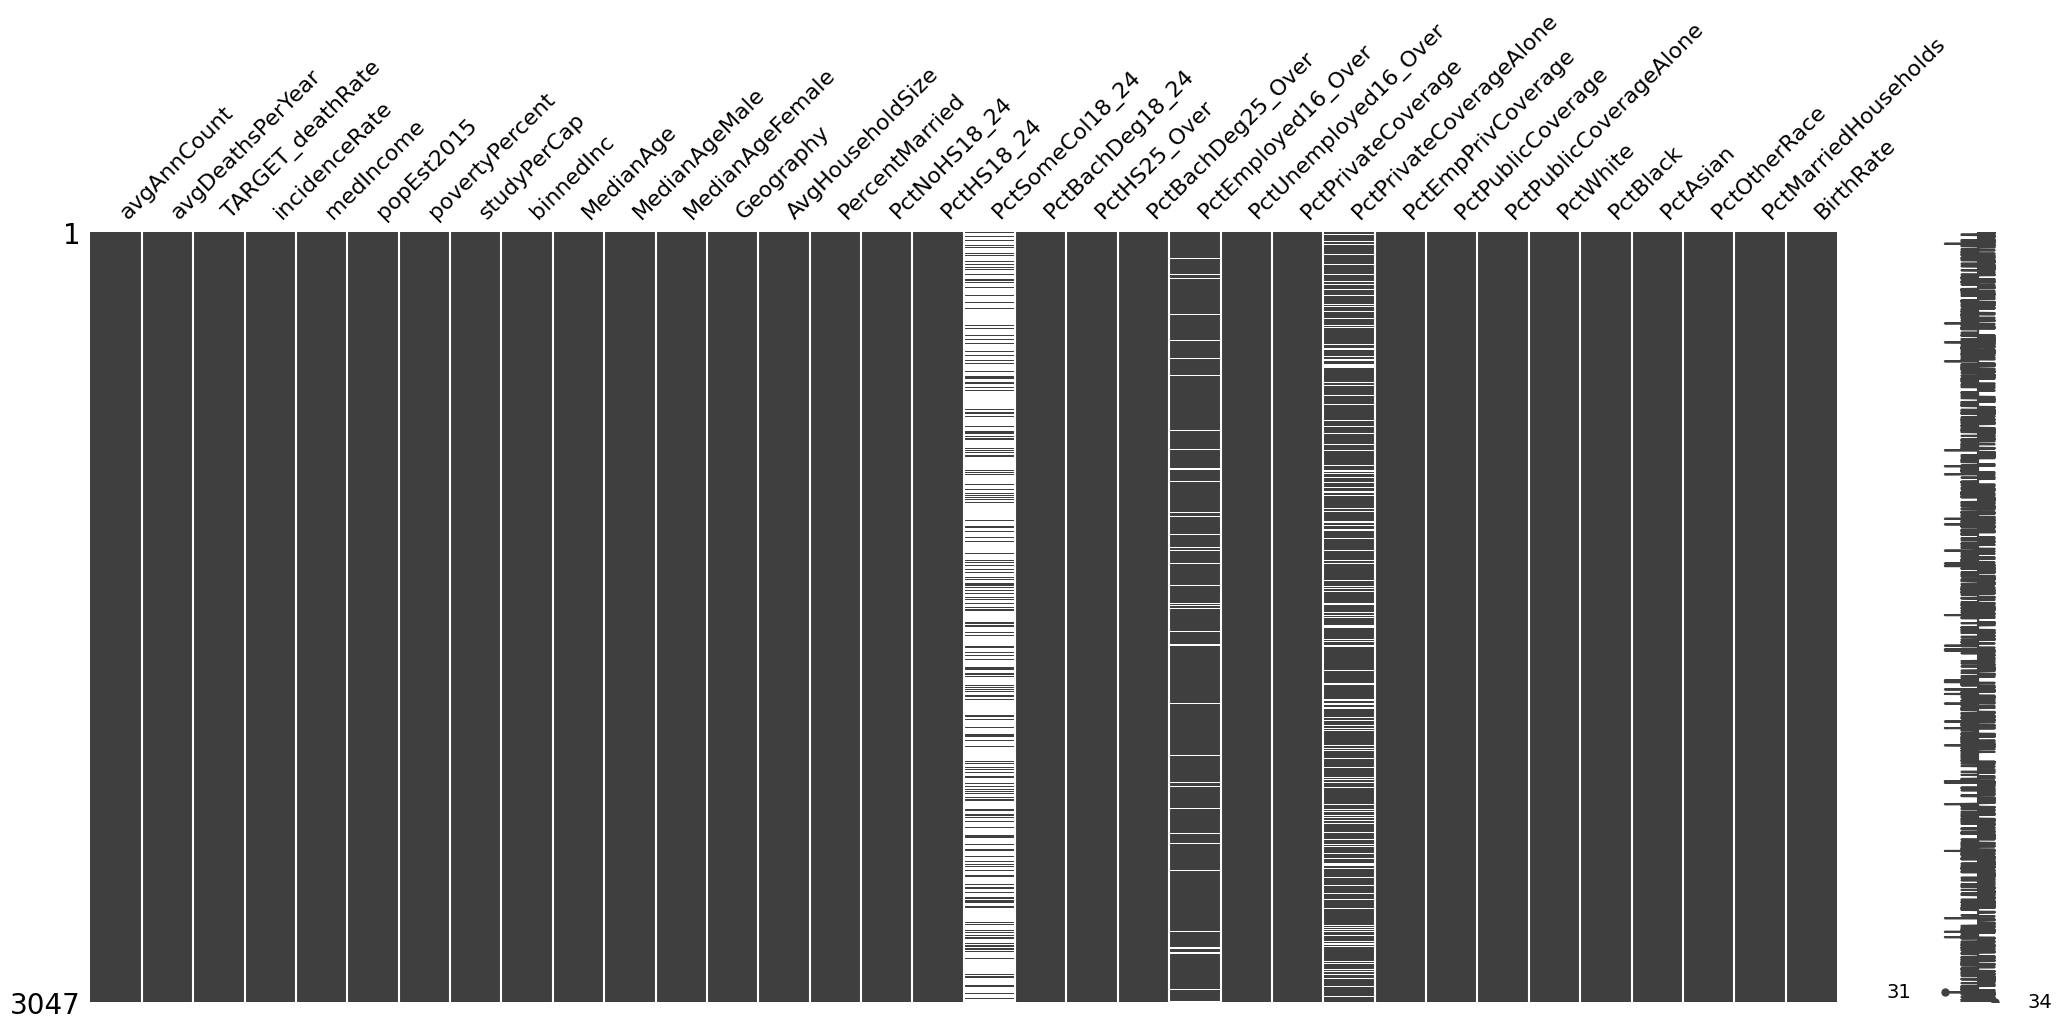

In [ ]:
msno.matrix(df)

In [43]:
zoom_df = df[['PctSomeCol18_24', 'PctBachDeg18_24', 'PctBachDeg25_Over', 'PctPrivateCoverageAlone', 'PctEmployed16_Over', 'TARGET_deathRate']]
zoom_df.describe()

,PctSomeCol18_24,PctBachDeg18_24,PctBachDeg25_Over,PctPrivateCoverageAlone,PctEmployed16_Over,TARGET_deathRate
count,762.000000,3047.000000,3047.000000,2438.000000,2895.000000,3047.000000
mean,40.977034,6.158287,13.282015,48.453774,54.152642,178.664063
std,11.115805,4.529059,5.394756,10.083006,8.315064,27.751511
min,7.100000,0.000000,2.500000,15.700000,17.600000,59.700000
25%,34.000000,3.100000,9.400000,41.000000,48.600000,161.200000
50%,40.400000,5.400000,12.300000,48.700000,54.500000,178.100000
75%,46.400000,8.200000,16.100000,55.600000,60.300000,195.200000
max,79.000000,51.800000,42.200000,78.900000,80.100000,362.800000


In [44]:
zoom_df.head(10)

,PctSomeCol18_24,PctBachDeg18_24,PctBachDeg25_Over,PctPrivateCoverageAlone,PctEmployed16_Over,TARGET_deathRate
0,42.1,6.9,19.6,NaN,51.9,164.9
1,64.0,7.5,22.7,53.8,55.9,161.3
2,NaN,9.5,16.0,43.5,45.9,174.7
3,36.1,2.5,9.3,40.3,48.3,194.8
4,40.0,2.0,15.0,43.9,48.2,144.4
5,NaN,4.5,11.9,38.8,44.1,176.0
6,NaN,5.8,11.9,35.0,51.8,175.9
7,36.5,2.2,11.3,33.1,40.9,183.6
8,NaN,1.4,12.0,37.8,39.5,190.5
9,NaN,7.1,16.2,NaN,56.6,177.8


### Plot correlation matrix

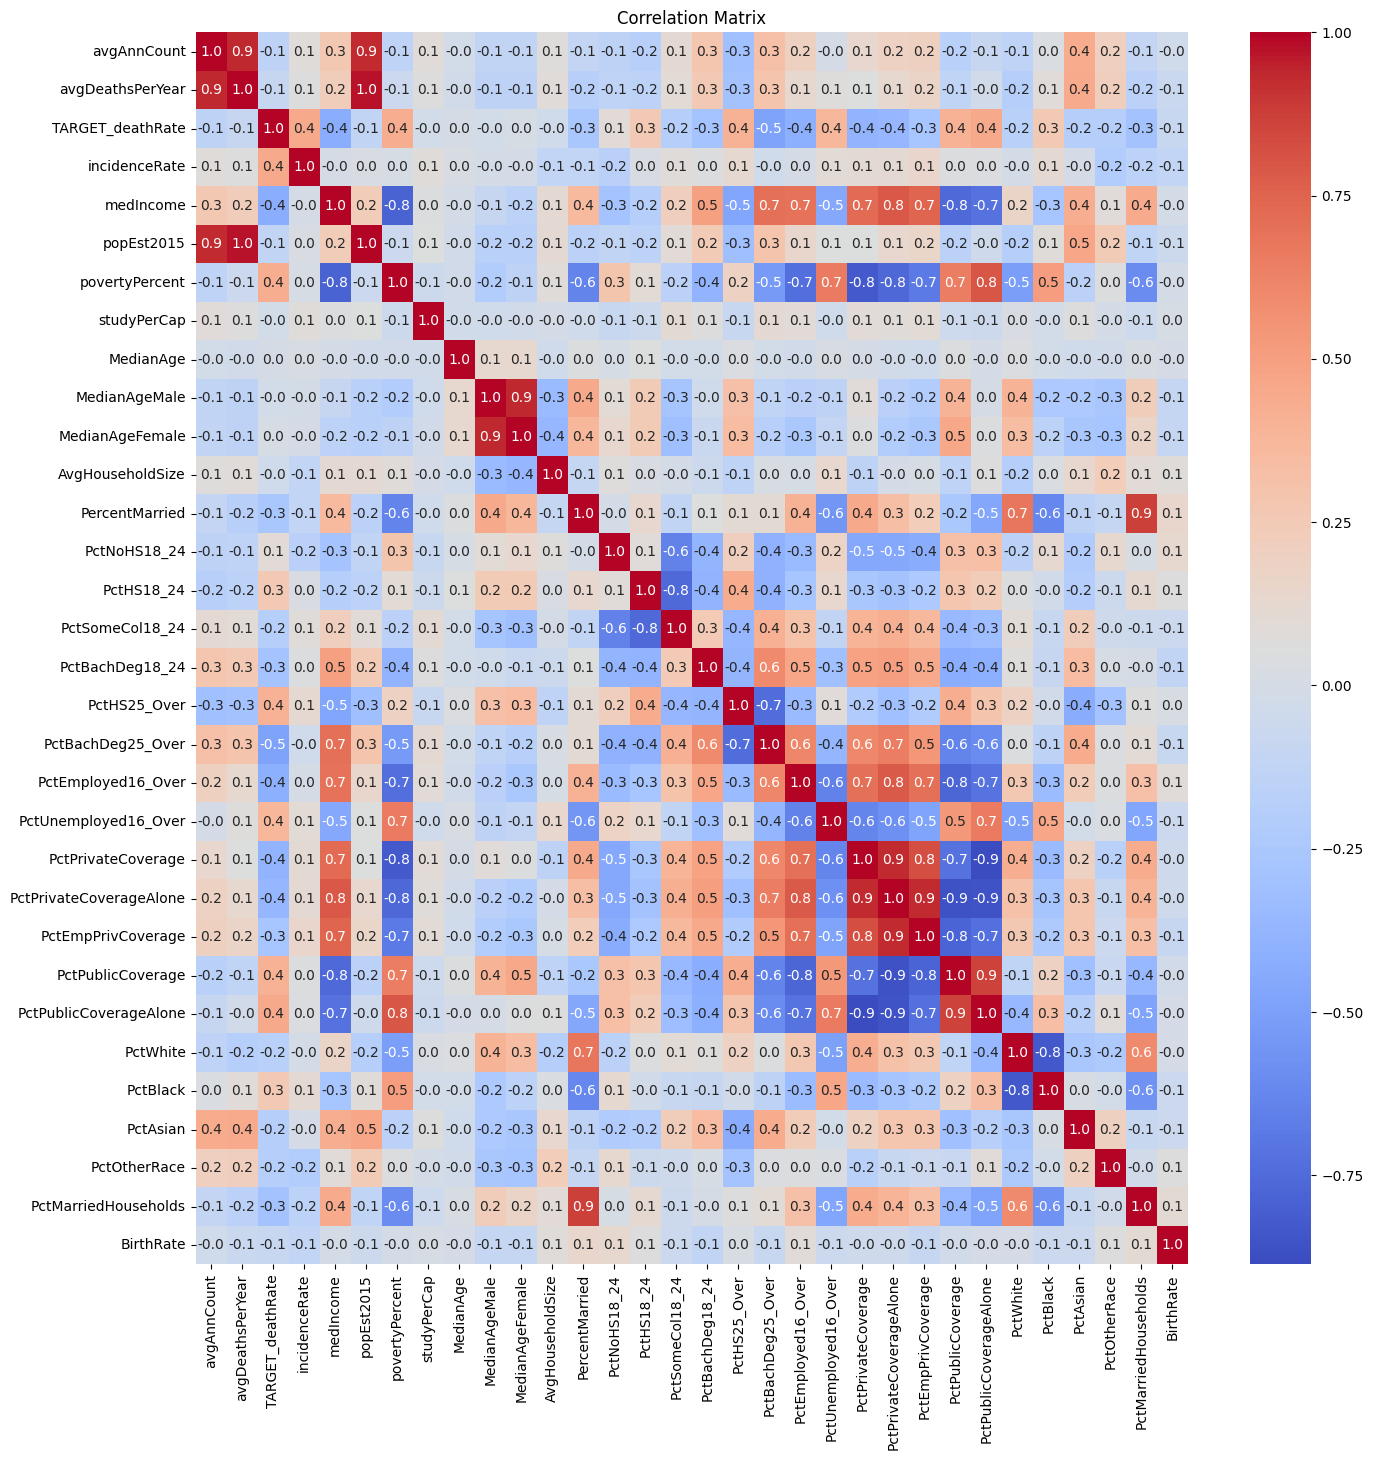

In [51]:
plt.figure(figsize=(16, 16))
correlation_matrix = df[df.select_dtypes(include=['float64', 'int64']).columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()